In [1]:
import os
import json
import torch
from PIL import Image
from transformers import CLIPModel, CLIPProcessor
from pathlib import Path
import re

In [2]:
# Load CLIP model and processor
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
import os
import json
import torch
import re
from PIL import Image
from transformers import CLIPModel, CLIPProcessor
from pathlib import Path

def extract_visible_text_from_prompt(prompt):
    """
    Extract all visible text from a prompt (text in quotes, signs, labels, etc.)
    """
    # Find all text in single quotes
    single_quotes = re.findall(r"'([^']+)'", prompt)
    
    # Find all text in double quotes
    double_quotes = re.findall(r'"([^"]+)"', prompt)
    
    # Combine all found text
    all_text = single_quotes + double_quotes
    
    # Remove duplicates while preserving order
    seen = set()
    unique_text = []
    for text in all_text:
        if text.lower() not in seen:
            seen.add(text.lower())
            unique_text.append(text)
    
    return unique_text

def create_text_prompt(visible_texts):
    """
    Create a prompt in the format: "An image where the text '...', '...', etc. is visible"
    """
    if not visible_texts:
        return None
    
    if len(visible_texts) == 1:
        return f"An image where the text '{visible_texts[0]}' is visible"
    elif len(visible_texts) == 2:
        return f"An image where the text '{visible_texts[0]}' and '{visible_texts[1]}' are visible"
    else:
        # Join all but last with commas, then add 'and' before the last one
        all_but_last = "', '".join(visible_texts[:-1])
        return f"An image where the text '{all_but_last}', and '{visible_texts[-1]}' are visible"

def load_prompts_from_json(json_path):
    """Load prompts from JSON file."""
    with open(json_path, 'r') as f:
        data = json.load(f)
    return data

def find_matching_prompt(folder_name, prompts_data):
    """
    Find the full prompt that matches the folder name (first ~20 chars).
    """
    folder_name_clean = folder_name.strip()
    
    # If prompts_data is a dict, extract prompts
    if isinstance(prompts_data, dict):
        if 'prompts' in prompts_data:
            prompt_list = prompts_data['prompts']
        elif 'captions' in prompts_data:
            prompt_list = prompts_data['captions']
        else:
            prompt_list = next((v for v in prompts_data.values() if isinstance(v, list)), [])
    else:
        prompt_list = prompts_data
    
    # Find matching prompt
    for prompt in prompt_list:
        if prompt.startswith(folder_name_clean) or folder_name_clean in prompt[:25]:
            return prompt
    
    # Fuzzy matching
    for prompt in prompt_list:
        if folder_name_clean[:15] in prompt[:25]:
            return prompt
    
    return None

def compute_clip_similarity(model, processor, image_path, text, device='cuda'):
    """Compute CLIP similarity between an image and text."""
    image = Image.open(image_path).convert('RGB')
    
    inputs = processor(text=[text], images=image, return_tensors="pt", padding=True)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    
    with torch.no_grad():
        outputs = model(**inputs)
        image_embeds = outputs.image_embeds
        text_embeds = outputs.text_embeds
        
        # Normalize embeddings
        image_embeds = image_embeds / image_embeds.norm(p=2, dim=-1, keepdim=True)
        text_embeds = text_embeds / text_embeds.norm(p=2, dim=-1, keepdim=True)
        
        # Compute cosine similarity
        similarity = (image_embeds @ text_embeds.T).squeeze()
    
    return similarity.cpu()

def process_folder_structure(root_folder, prompts_json_path, output_folder, model, processor, device='cuda'):
    """
    Process the folder structure and compute layer averages across ALL prompts and seeds.
    """
    root_path = Path(root_folder)
    output_path = Path(output_folder)
    output_path.mkdir(parents=True, exist_ok=True)
    
    # Load prompts
    prompts_data = load_prompts_from_json(prompts_json_path)
    
    # Dictionary to accumulate similarities per layer across ALL prompts and seeds
    all_layer_similarities = {i: [] for i in range(19)}
    
    # Iterate through prompt folders
    for prompt_folder in sorted(root_path.iterdir()):
        if not prompt_folder.is_dir():
            continue
        
        prompt_folder_name = prompt_folder.name
        
        # Find matching prompt
        full_prompt = find_matching_prompt(prompt_folder_name, prompts_data)
        if full_prompt is None:
            continue
        
        # Extract visible text
        visible_texts = extract_visible_text_from_prompt(full_prompt)
        if not visible_texts:
            continue
        
        # Create text-focused prompt
        text_prompt = create_text_prompt(visible_texts)
        
        # Iterate through seed folders
        for seed_folder in sorted(prompt_folder.iterdir()):
            if not seed_folder.is_dir():
                continue
            
            # Process layers 0-18
            for layer_idx in range(19):
                image_path = seed_folder / f"layer_{layer_idx}.png"
                
                if not image_path.exists():
                    continue
                
                # Compute similarity with text-focused prompt
                similarity = compute_clip_similarity(model, processor, image_path, text_prompt, device)
                all_layer_similarities[layer_idx].append(similarity)
    
    # Compute mean similarity for each layer across ALL data
    layer_averages = []
    for layer_idx in range(19):
        if all_layer_similarities[layer_idx]:
            mean_sim = torch.stack(all_layer_similarities[layer_idx]).mean()
            layer_averages.append(mean_sim.item())
        else:
            layer_averages.append(0.0)
    
    # Print layer averages
    print("\nLayer Averages Across All Prompts and Seeds:")
    print("=" * 50)
    for layer_idx, avg in enumerate(layer_averages):
        print(f"Layer {layer_idx:2d}: {avg:.6f}")
    print("=" * 50)
    print(f"Overall Average: {sum(layer_averages) / len(layer_averages):.6f}")
    
    # Save layer averages as tensor
    layer_averages_tensor = torch.tensor(layer_averages)
    output_file = output_path / "layer_averages_all.pt"
    torch.save(layer_averages_tensor, output_file)
    print(f"\nSaved layer averages to {output_file}")

In [ ]:
root_folder = "/export/home/ru63zus/repos/contrastive-skip-layer-guidance/experiments/flux_layer_ablation_20251003_082325"  
prompts_json_path = "/export/home/ru63zus/repos/contrastive-skip-layer-guidance/prompt_datasets/aesthetics/aesthetic_pairs_simple.json"  
output_folder = "/export/home/ru63zus/repos/contrastive-skip-layer-guidance/clips"  

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# Load CLIP model and processor
print("Loading CLIP model...")
model = CLIPModel.from_pretrained("openai/clip-vit-large-patch14")
processor = CLIPProcessor.from_pretrained("openai/clip-vit-large-patch14")

# IMPORTANT: Move model to device AFTER loading
model = model.to(device)
model.eval()

# Process folders
process_folder_structure(root_folder, prompts_json_path, output_folder, model, processor, device)

print("\nProcessing complete!")

Using device: cuda
Loading CLIP model...


Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]


Layer Averages Across All Prompts and Seeds:
Layer  0: 0.298706
Layer  1: 0.285516
Layer  2: 0.234844
Layer  3: 0.278941
Layer  4: 0.277572
Layer  5: 0.284243
Layer  6: 0.285677
Layer  7: 0.272364
Layer  8: 0.276683
Layer  9: 0.289283
Layer 10: 0.289770
Layer 11: 0.279953
Layer 12: 0.279240
Layer 13: 0.287657
Layer 14: 0.279355
Layer 15: 0.285246
Layer 16: 0.282978
Layer 17: 0.280644
Layer 18: 0.295839
Layer 19: 0.000000
Overall Average: 0.267226

Saved layer averages to /export/home/ru63zus/repos/contrastive-skip-layer-guidance/clips/layer_averages_all.pt

Processing complete!


In [105]:
layer_sims = torch.load('/export/home/ru63zus/repos/contrastive-skip-layer-guidance/clips/layer_averages_all.pt')[3:19]
print(layer_sims.shape)

text_results = torch.tensor([0.231960, 0.230319, 0.147445, 0.211755, 0.210885, 
                     0.202199, 0.216633, 0.206342, 0.222167, 0.195722, 
                     0.210882, 0.198651, 0.204099, 0.205225, 0.216540, 
                     0.215737, 0.215030, 0.216897, 0.216760])[3:]

# Compute Pearson correlation
correlation = torch.corrcoef(torch.stack([layer_sims, text_results]))[0, 1]

print(f"Pearson correlation: {correlation:.4f}")

torch.Size([16])
Pearson correlation: -0.0458


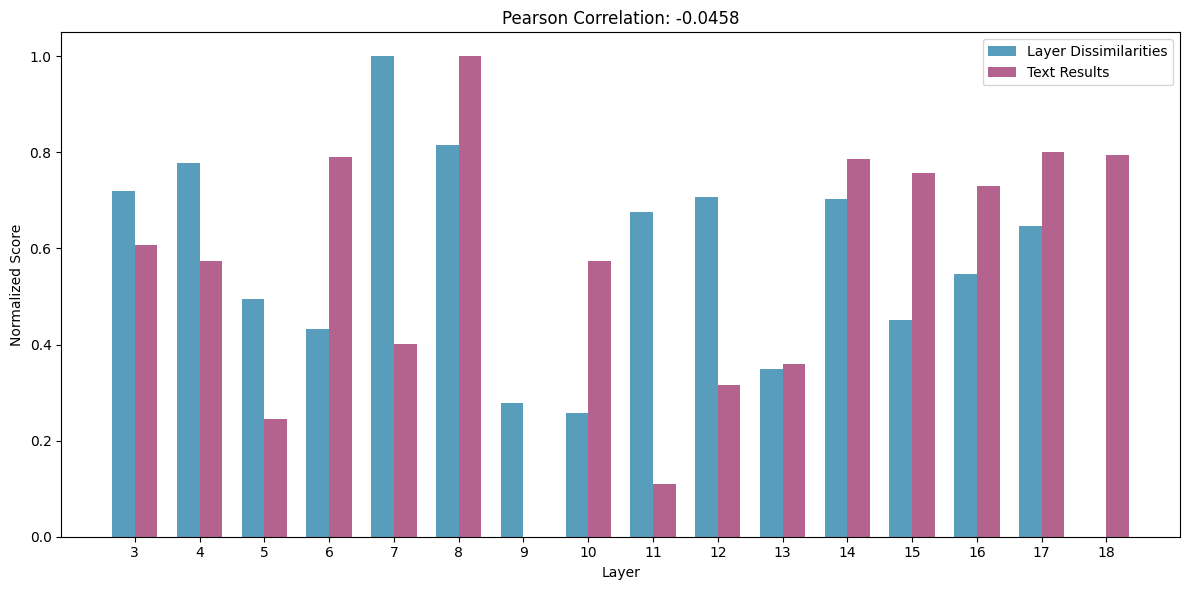

In [106]:
import matplotlib.pyplot as plt
import numpy as np

layers = np.arange(3, 3 + len(layer_sims))

# Compute dissimilarity for layer_similarities only
layer_dissim = layer_sims

# Normalize to [0, 1]
layer_norm = 1- ((layer_dissim - layer_dissim.min()) / (layer_dissim.max() - layer_dissim.min()))
text_norm = (text_results - text_results.min()) / (text_results.max() - text_results.min())

x = np.arange(len(layers))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - width/2, layer_norm.numpy(), width, label='Layer Dissimilarities', color='#2E86AB', alpha=0.8)
ax.bar(x + width/2, text_norm.numpy(), width, label='Text Results', color='#A23B72', alpha=0.8)

# Recompute correlation
correlation_new = torch.corrcoef(torch.stack([layer_dissim, text_results]))[0, 1]

ax.set_xlabel('Layer')
ax.set_ylabel('Normalized Score')
ax.set_title(f'Pearson Correlation: {correlation_new:.4f}')
ax.set_xticks(x)
ax.set_xticklabels(layers)
ax.legend()
plt.tight_layout()
plt.show()


In [1]:
import os
import json
import torch
import gc
from PIL import Image
from transformers import CLIPModel, CLIPProcessor
from pathlib import Path
import re
import random
import argparse
from FLUX_custom_pipeline import FluxPipeline

def flush():
    gc.collect()
    torch.cuda.empty_cache()


dataset = json.load(open('/export/home/ru63zus/repos/contrastive-skip-layer-guidance/prompt_datasets/hands/hands_pairs.json', "r"))

# Load Models
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
pipe = FluxPipeline.from_pretrained("black-forest-labs/FLUX.1-dev", torch_dtype=torch.float16)
pipe.enable_model_cpu_offload()

clip_scores = []

for prompt_pair in dataset[:2]:
    print(f"Generating image for positive prompt: {prompt_pair['positive']}")
    images = []
    random_seed = random.randint(0, 2**32 - 1)

    for i in range(2):
        pipe.skipped_layers = [i]
        image = pipe(
            prompt_pair['positive'],
            negative_prompt=prompt_pair['positive'],
            num_inference_steps=28,
            max_sequence_length=256,
            true_cfg_scale=0.0,
            generator=torch.Generator("cpu").manual_seed(random_seed)
        ).images[0]
        images.append(image)
    print(f"Calculating CLIP scores.")


    # Prepare inputs for CLIP
    positive_inputs = processor(
        text=[prompt_pair['positive']] * len(images),
        images=images,
        return_tensors="pt",
        padding=True
    )
    
    negative_inputs = processor(
        text=[prompt_pair['negative']] * len(images),
        images=images,
        return_tensors="pt",
        padding=True
    )
    
    # Calculate CLIP scores
    with torch.no_grad():
        positive_outputs = model(**positive_inputs)
        positive_scores = positive_outputs.logits_per_image.diagonal().cpu().tolist()
        
        negative_outputs = model(**negative_inputs)
        negative_scores = negative_outputs.logits_per_image.diagonal().cpu().tolist()
    
    # Store results
    result = {
        'positive_prompt': prompt_pair['positive'],
        'negative_prompt': prompt_pair['negative'],
        'positive_scores': positive_scores,
        'negative_scores': negative_scores,
        'avg_positive_score': sum(positive_scores) / len(positive_scores),
        'avg_negative_score': sum(negative_scores) / len(negative_scores),
        'seed': random_seed
    }
    
    clip_scores.append(result)
    
    print(f"Avg Positive Score: {result['avg_positive_score']:.4f}, Avg Negative Score: {result['avg_negative_score']:.4f}")
    
    # Clean up
    flush()

# Save results
output_path = f'clip_scores_test.json'
with open(output_path, 'w') as f:
    json.dump(clip_scores, indent=2, fp=f)

print(f"\nResults saved to {output_path}")

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

You set `add_prefix_space`. The tokenizer needs to be converted from the slow tokenizers
`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

...

Calculating CLIP scores.
Avg Positive Score: 18.2498, Avg Negative Score: 20.0807
Generating image for positive prompt: Close-up shot of an artist painting on canvas, vibrant colors, human hands visible holding a paintbrush
Performing Skip-Layer Guidance with scale 0.0 for layers [0].


  0%|          | 0/28 [00:00<?, ?it/s]

Performing Skip-Layer Guidance with scale 0.0 for layers [1].


  0%|          | 0/28 [00:00<?, ?it/s]

Calculating CLIP scores.
Avg Positive Score: 22.7285, Avg Negative Score: 23.5178

Results saved to clip_scores_test.json


Correlation (diff): -0.0748 | Spearman: -0.0265 (p=0.9225)
Correlation (pos):  -0.0665 | Spearman: -0.0912 (p=0.7370)
Correlation (neg):  -0.0253 | Spearman: 0.0147 (p=0.9569)


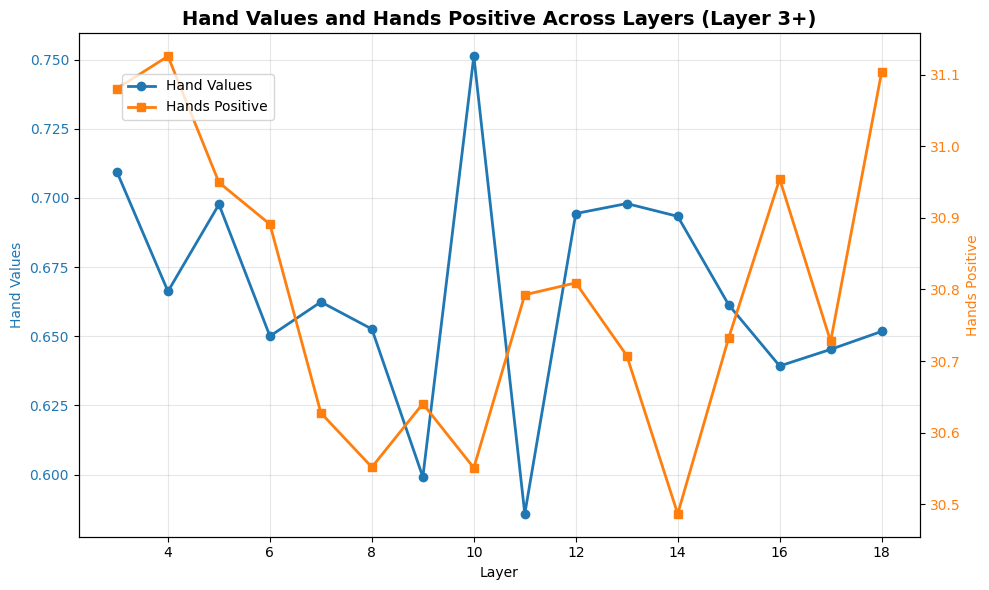

In [2]:
import torch
import json
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

hand_values = torch.tensor([
    0.186552,
    0.136625,
    0.133595,
    0.709330,
    0.666218,
    0.697655,
    0.650028,
    0.662389,
    0.652602,
    0.599139,
    0.751199,
    0.585819,
    0.694342,
    0.697953,
    0.693330,
    0.661349,
    0.639252,
    0.645254,
    0.651743
])

hands_data = json.load(open('/export/home/ru63zus/repos/contrastive-skip-layer-guidance/clip_scores_hands.json', "r"))
hands_tensor_positive = torch.stack([torch.tensor(hands_data[i]['positive_scores']) for i in range(50)])
hands_tensor_negative = torch.stack([torch.tensor(hands_data[i]['negative_scores']) for i in range(50)])

hands_positive = hands_tensor_positive.mean(dim=0) 
hands_negative = hands_tensor_negative.mean(dim=0)

hand_diffs = ((hands_tensor_positive - hands_tensor_negative) / hands_tensor_positive).mean(dim=0)

# Cosine similarity correlations
correlation_diff = torch.cosine_similarity(
    hand_diffs[3:] - hand_diffs[3:].mean(), 
    hand_values[3:] - hand_values[3:].mean(), 
    dim=0
)
correlation_pos = torch.cosine_similarity(
    hands_positive[3:] - hands_positive[3:].mean(), 
    hand_values[3:] - hand_values[3:].mean(), 
    dim=0
)
correlation_neg = torch.cosine_similarity(
    hands_negative[3:] - hands_negative[3:].mean(), 
    hand_values[3:] - hand_values[3:].mean(), 
    dim=0
)

# Spearman correlations
spearman_diff, p_diff = spearmanr(hand_diffs[3:].numpy(), hand_values[3:].numpy())
spearman_pos, p_pos = spearmanr(hands_positive[3:].numpy(), hand_values[3:].numpy())
spearman_neg, p_neg = spearmanr(hands_negative[3:].numpy(), hand_values[3:].numpy())

print(f"Correlation (diff): {correlation_diff:.4f} | Spearman: {spearman_diff:.4f} (p={p_diff:.4f})")
print(f"Correlation (pos):  {correlation_pos:.4f} | Spearman: {spearman_pos:.4f} (p={p_pos:.4f})")
print(f"Correlation (neg):  {correlation_neg:.4f} | Spearman: {spearman_neg:.4f} (p={p_neg:.4f})")

# Create plot
layers = list(range(3, len(hand_values)))

fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot hand_values on primary y-axis
color1 = 'tab:blue'
ax1.set_xlabel('Layer')
ax1.set_ylabel('Hand Values', color=color1)
ax1.plot(layers, hand_values[3:].numpy(), marker='o', color=color1, label='Hand Values', linewidth=2)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.grid(True, alpha=0.3)

# Create secondary y-axis for hands_positive
ax2 = ax1.twinx()
color2 = 'tab:orange'
ax2.set_ylabel('Hands Positive', color=color2)
ax2.plot(layers, hands_positive[3:].numpy(), marker='s', color=color2, label='Hands Positive', linewidth=2)
ax2.tick_params(axis='y', labelcolor=color2)

# Add title and legends
plt.title('Hand Values and Hands Positive Across Layers (Layer 3+)', fontsize=14, fontweight='bold')
fig.legend(loc='upper left', bbox_to_anchor=(0.12, 0.88))

plt.tight_layout()
plt.show()

Correlation (diff): -0.3139 | Spearman: -0.4941 (p=0.0517)
Correlation (pos):  -0.3758 | Spearman: -0.4029 (p=0.1217)
Correlation (neg):  -0.2979 | Spearman: -0.2912 (p=0.2739)


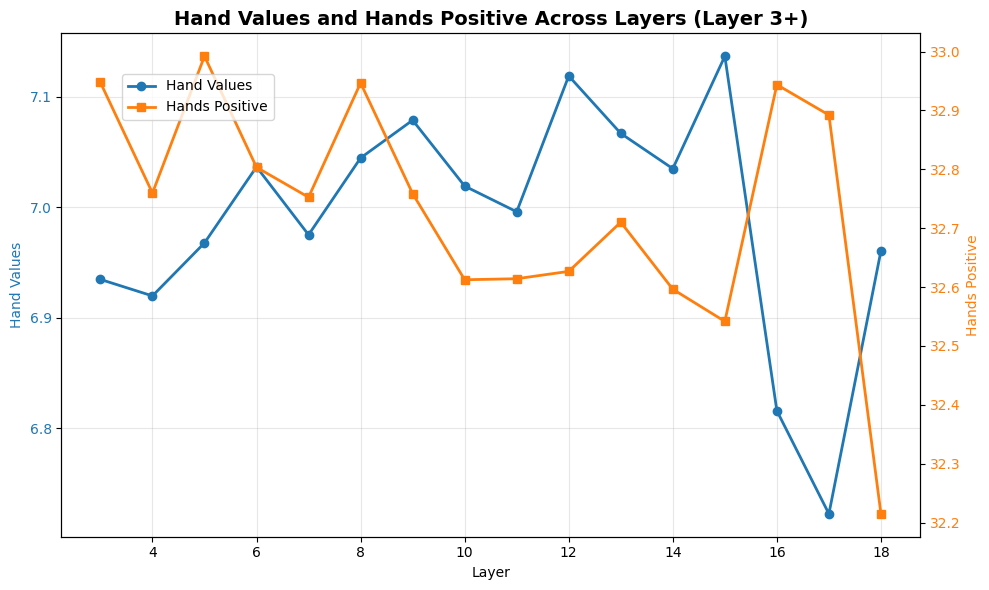

In [1]:
import torch
import json
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

hand_values = torch.tensor([
    6.182411,  # layer_0
    5.620659,  # layer_1
    5.538202,  # layer_2
    6.934737,  # layer_3
    6.919821,  # layer_4
    6.967773,  # layer_5
    7.036552,  # layer_6
    6.975098,  # layer_7
    7.044626,  # layer_8
    7.078791,  # layer_9
    7.019176,  # layer_10
    6.995934,  # layer_11
    7.118817,  # layer_12
    7.066835,  # layer_13
    7.034940,  # layer_14
    7.136667,  # layer_15
    6.815899,  # layer_16
    6.722664,  # layer_17
    6.960558,  # layer_18
])

hands_data = json.load(open('/export/home/ru63zus/repos/contrastive-skip-layer-guidance/clip_scores_aesthetics.json', "r"))
hands_tensor_positive = torch.stack([torch.tensor(hands_data[i]['positive_scores']) for i in range(50)])
hands_tensor_negative = torch.stack([torch.tensor(hands_data[i]['negative_scores']) for i in range(50)])

hands_positive = hands_tensor_positive.mean(dim=0) 
hands_negative = hands_tensor_negative.mean(dim=0)

hand_diffs = ((hands_tensor_positive - hands_tensor_negative) / hands_tensor_positive).mean(dim=0)

# Cosine similarity correlations
correlation_diff = torch.cosine_similarity(
    hand_diffs[3:] - hand_diffs[3:].mean(), 
    hand_values[3:] - hand_values[3:].mean(), 
    dim=0
)
correlation_pos = torch.cosine_similarity(
    hands_positive[3:] - hands_positive[3:].mean(), 
    hand_values[3:] - hand_values[3:].mean(), 
    dim=0
)
correlation_neg = torch.cosine_similarity(
    hands_negative[3:] - hands_negative[3:].mean(), 
    hand_values[3:] - hand_values[3:].mean(), 
    dim=0
)

# Spearman correlations
spearman_diff, p_diff = spearmanr(hand_diffs[3:].numpy(), hand_values[3:].numpy())
spearman_pos, p_pos = spearmanr(hands_positive[3:].numpy(), hand_values[3:].numpy())
spearman_neg, p_neg = spearmanr(hands_negative[3:].numpy(), hand_values[3:].numpy())

print(f"Correlation (diff): {correlation_diff:.4f} | Spearman: {spearman_diff:.4f} (p={p_diff:.4f})")
print(f"Correlation (pos):  {correlation_pos:.4f} | Spearman: {spearman_pos:.4f} (p={p_pos:.4f})")
print(f"Correlation (neg):  {correlation_neg:.4f} | Spearman: {spearman_neg:.4f} (p={p_neg:.4f})")

# Create plot
layers = list(range(3, len(hand_values)))

fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot hand_values on primary y-axis
color1 = 'tab:blue'
ax1.set_xlabel('Layer')
ax1.set_ylabel('Hand Values', color=color1)
ax1.plot(layers, hand_values[3:].numpy(), marker='o', color=color1, label='Hand Values', linewidth=2)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.grid(True, alpha=0.3)

# Create secondary y-axis for hands_positive
ax2 = ax1.twinx()
color2 = 'tab:orange'
ax2.set_ylabel('Hands Positive', color=color2)
ax2.plot(layers, hands_positive[3:].numpy(), marker='s', color=color2, label='Hands Positive', linewidth=2)
ax2.tick_params(axis='y', labelcolor=color2)

# Add title and legends
plt.title('Hand Values and Hands Positive Across Layers (Layer 3+)', fontsize=14, fontweight='bold')
fig.legend(loc='upper left', bbox_to_anchor=(0.12, 0.88))

plt.tight_layout()
plt.show()

Correlation (diff): -0.1933
Correlation (pos):  -0.2282
Correlation (neg):  0.0308


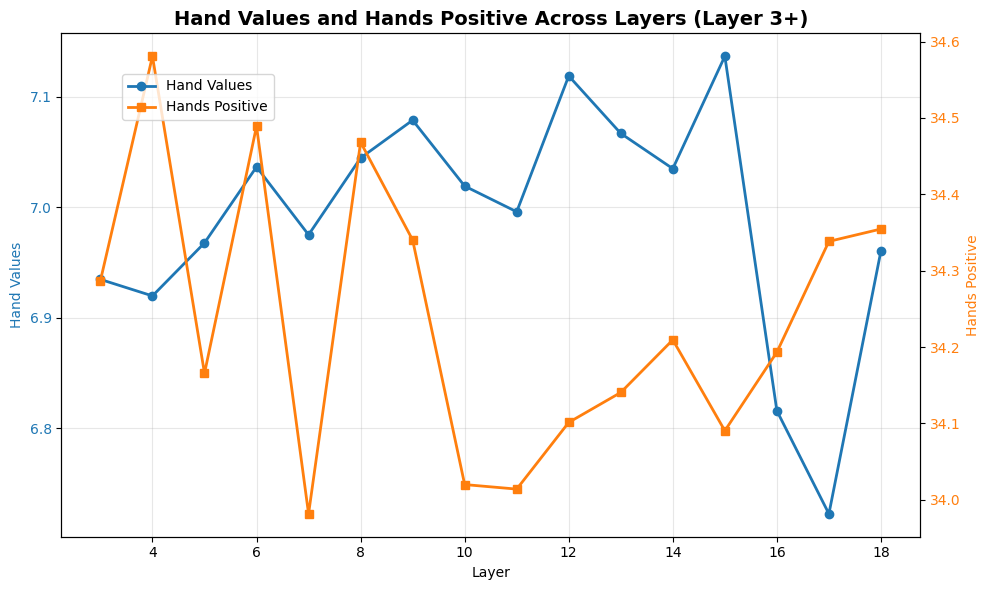

In [13]:
hands_values = torch.tensor([
    0.210832,  # layer_0
    0.213569,  # layer_1
    0.202250,  # layer_2
    0.222501,  # layer_3
    0.234267,  # layer_4
    0.223289,  # layer_5
    0.217554,  # layer_6
    0.220197,  # layer_7
    0.208817,  # layer_8
    0.235654,  # layer_9
    0.219634,  # layer_10
    0.207371,  # layer_11
    0.213037,  # layer_12
    0.202450,  # layer_13
    0.223037,  # layer_14
    0.234514,  # layer_15
    0.214499,  # layer_16
    0.221948,  # layer_17
    0.216414,  # layer_18
])

hands_data = json.load(open('/export/home/ru63zus/repos/contrastive-skip-layer-guidance/clip_scores_text.json', "r"))
hands_tensor_positive = torch.stack([torch.tensor(hands_data[i]['positive_scores']) for i in range(50)])
hands_tensor_negative = torch.stack([torch.tensor(hands_data[i]['negative_scores']) for i in range(50)])

hands_positive = hands_tensor_positive.mean(dim=0) 
hands_negative = hands_tensor_negative.mean(dim=0)

hand_diffs = ((hands_tensor_positive - hands_tensor_negative) / hands_tensor_positive).mean(dim=0)

correlation_diff = torch.cosine_similarity(
    hand_diffs[3:] - hand_diffs[3:].mean(), 
    hand_values[3:] - hand_values[3:].mean(), 
    dim=0
)
correlation_pos = torch.cosine_similarity(
    hands_positive[3:] - hands_positive[3:].mean(), 
    hand_values[3:] - hand_values[3:].mean(), 
    dim=0
)
correlation_neg = torch.cosine_similarity(
    hands_negative[3:] - hands_negative[3:].mean(), 
    hand_values[3:] - hand_values[3:].mean(), 
    dim=0
)
print(f"Correlation (diff): {correlation_diff:.4f}")
print(f"Correlation (pos):  {correlation_pos:.4f}")
print(f"Correlation (neg):  {correlation_neg:.4f}")

# Create plot
layers = list(range(3, len(hand_values)))

fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot hand_values on primary y-axis
color1 = 'tab:blue'
ax1.set_xlabel('Layer')
ax1.set_ylabel('Hand Values', color=color1)
ax1.plot(layers, hand_values[3:].numpy(), marker='o', color=color1, label='Hand Values', linewidth=2)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.grid(True, alpha=0.3)

# Create secondary y-axis for hands_positive
ax2 = ax1.twinx()
color2 = 'tab:orange'
ax2.set_ylabel('Hands Positive', color=color2)
ax2.plot(layers, hands_positive[3:].numpy(), marker='s', color=color2, label='Hands Positive', linewidth=2)
ax2.tick_params(axis='y', labelcolor=color2)

# Add title and legends
plt.title('Hand Values and Hands Positive Across Layers (Layer 3+)', fontsize=14, fontweight='bold')
fig.legend(loc='upper left', bbox_to_anchor=(0.12, 0.88))

plt.tight_layout()
plt.show()

Correlation (diff): 0.3712 | Spearman: 0.5000 (p=0.6667)
Correlation (pos):  0.3691 | Spearman: 0.5000 (p=0.6667)
Correlation (neg):  0.3841 | Spearman: 0.5000 (p=0.6667)


ValueError: x and y must have same first dimension, but have shapes (19,) and (3,)

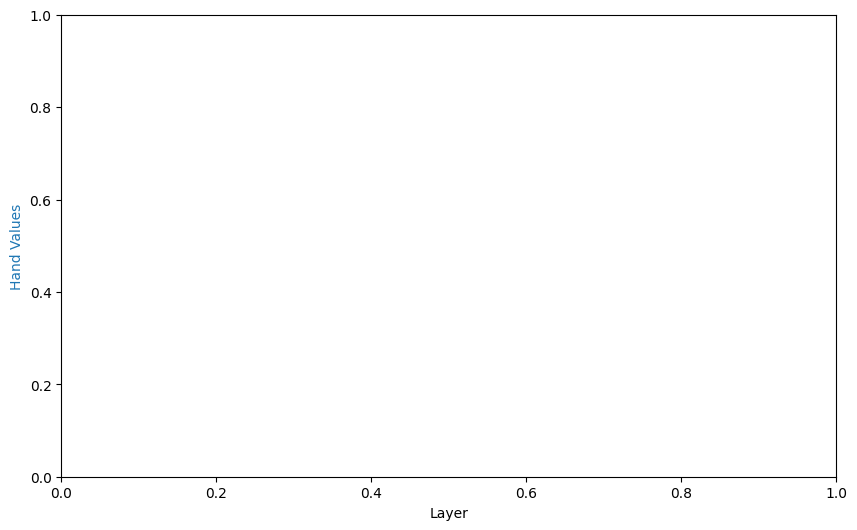

In [4]:
import torch
import json
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

hand_values = torch.tensor([
    0.186552,
    0.136625,
    0.133595,
    0.709330,
    0.666218,
    0.697655,
    0.650028,
    0.662389,
    0.652602,
    0.599139,
    0.751199,
    0.585819,
    0.694342,
    0.697953,
    0.693330,
    0.661349,
    0.639252,
    0.645254,
    0.651743
])

hands_data = json.load(open('/export/home/ru63zus/repos/contrastive-skip-layer-guidance/clip_scores_hands.json', "r"))
hands_tensor_positive = torch.stack([torch.tensor(hands_data[i]['positive_scores']) for i in range(50)])
hands_tensor_negative = torch.stack([torch.tensor(hands_data[i]['negative_scores']) for i in range(50)])

hands_positive = hands_tensor_positive.mean(dim=0) 
hands_negative = hands_tensor_negative.mean(dim=0)

hand_diffs = ((hands_tensor_positive - hands_tensor_negative) / hands_tensor_positive).mean(dim=0)

# Cosine similarity correlations
correlation_diff = torch.cosine_similarity(
    hand_diffs[:3] - hand_diffs[:3].mean(), 
    hand_values[:3] - hand_values[:3].mean(), 
    dim=0
)
correlation_pos = torch.cosine_similarity(
    hands_positive[:3] - hands_positive[:3].mean(), 
    hand_values[:3] - hand_values[:3].mean(), 
    dim=0
)
correlation_neg = torch.cosine_similarity(
    hands_negative[:3] - hands_negative[:3].mean(), 
    hand_values[:3] - hand_values[:3].mean(), 
    dim=0
)

# Spearman correlations
spearman_diff, p_diff = spearmanr(hand_diffs[:3].numpy(), hand_values[:3].numpy())
spearman_pos, p_pos = spearmanr(hands_positive[:3].numpy(), hand_values[:3].numpy())
spearman_neg, p_neg = spearmanr(hands_negative[:3].numpy(), hand_values[:3].numpy())

print(f"Correlation (diff): {correlation_diff:.4f} | Spearman: {spearman_diff:.4f} (p={p_diff:.4f})")
print(f"Correlation (pos):  {correlation_pos:.4f} | Spearman: {spearman_pos:.4f} (p={p_pos:.4f})")
print(f"Correlation (neg):  {correlation_neg:.4f} | Spearman: {spearman_neg:.4f} (p={p_neg:.4f})")

# Create plot
layers = list(range(len(hand_values)))

fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot hand_values on primary y-axis
color1 = 'tab:blue'
ax1.set_xlabel('Layer')
ax1.set_ylabel('Hand Values', color=color1)
ax1.plot(layers, hand_values[:3].numpy(), marker='o', color=color1, label='Hand Values', linewidth=2)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.grid(True, alpha=0.3)

# Create secondary y-axis for hands_positive
ax2 = ax1.twinx()
color2 = 'tab:orange'
ax2.set_ylabel('Hands Positive', color=color2)
ax2.plot(layers, hands_positive[:].numpy(), marker='s', color=color2, label='Hands Positive', linewidth=2)
ax2.tick_params(axis='y', labelcolor=color2)

# Add title and legends
plt.title('Hand Values and Hands Positive Across Layers (Layer 3+)', fontsize=14, fontweight='bold')
fig.legend(loc='upper left', bbox_to_anchor=(0.12, 0.88))

plt.tight_layout()
plt.show()

Correlation (diff): 0.4152 | Spearman: -0.1351 (p=0.5814)
Correlation (pos):  0.4354 | Spearman: 0.4298 (p=0.0663)
Correlation (neg):  0.4485 | Spearman: 0.7930 (p=0.0001)


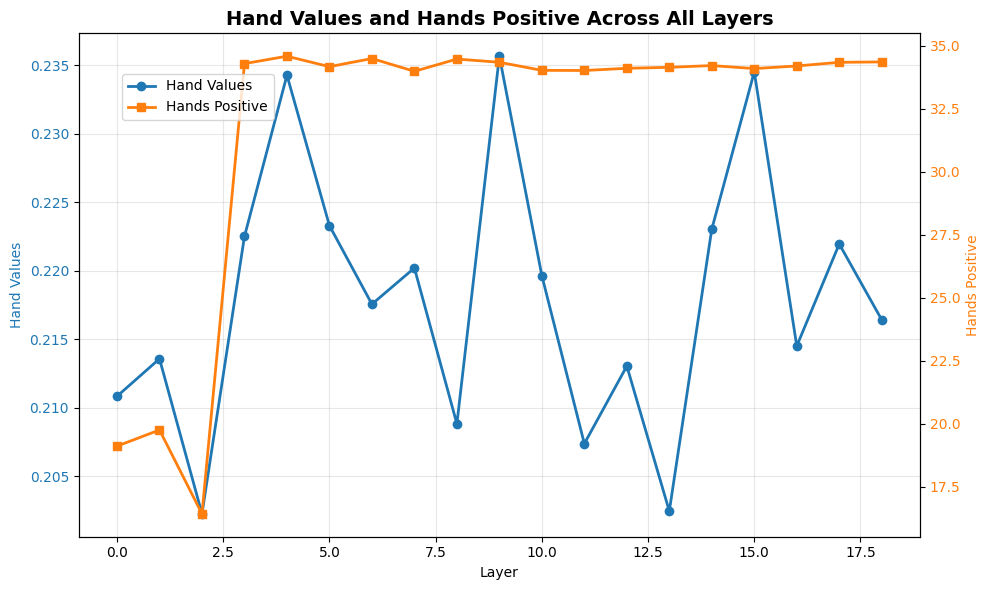

In [6]:
import torch
import json
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

hands_values = torch.tensor([
    0.210832,  # layer_0
    0.213569,  # layer_1
    0.202250,  # layer_2
    0.222501,  # layer_3
    0.234267,  # layer_4
    0.223289,  # layer_5
    0.217554,  # layer_6
    0.220197,  # layer_7
    0.208817,  # layer_8
    0.235654,  # layer_9
    0.219634,  # layer_10
    0.207371,  # layer_11
    0.213037,  # layer_12
    0.202450,  # layer_13
    0.223037,  # layer_14
    0.234514,  # layer_15
    0.214499,  # layer_16
    0.221948,  # layer_17
    0.216414,  # layer_18
])

hands_data = json.load(open('/export/home/ru63zus/repos/contrastive-skip-layer-guidance/clip_scores_text.json', "r"))
hands_tensor_positive = torch.stack([torch.tensor(hands_data[i]['positive_scores']) for i in range(50)])
hands_tensor_negative = torch.stack([torch.tensor(hands_data[i]['negative_scores']) for i in range(50)])

hands_positive = hands_tensor_positive.mean(dim=0) 
hands_negative = hands_tensor_negative.mean(dim=0)

hand_diffs = ((hands_tensor_positive - hands_tensor_negative) / hands_tensor_positive).mean(dim=0)

# Cosine similarity correlations - ALL LAYERS
correlation_diff = torch.cosine_similarity(
    hand_diffs - hand_diffs.mean(), 
    hands_values - hands_values.mean(), 
    dim=0
)
correlation_pos = torch.cosine_similarity(
    hands_positive - hands_positive.mean(), 
    hands_values - hands_values.mean(), 
    dim=0
)
correlation_neg = torch.cosine_similarity(
    hands_negative - hands_negative.mean(), 
    hands_values - hands_values.mean(), 
    dim=0
)

# Spearman correlations - ALL LAYERS
spearman_diff, p_diff = spearmanr(hand_diffs.numpy(), hands_values.numpy())
spearman_pos, p_pos = spearmanr(hands_positive.numpy(), hands_values.numpy())
spearman_neg, p_neg = spearmanr(hands_negative.numpy(), hands_values.numpy())

print(f"Correlation (diff): {correlation_diff:.4f} | Spearman: {spearman_diff:.4f} (p={p_diff:.4f})")
print(f"Correlation (pos):  {correlation_pos:.4f} | Spearman: {spearman_pos:.4f} (p={p_pos:.4f})")
print(f"Correlation (neg):  {correlation_neg:.4f} | Spearman: {spearman_neg:.4f} (p={p_neg:.4f})")

# Create plot - ALL LAYERS
layers = list(range(len(hands_values)))

fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot hand_values on primary y-axis
color1 = 'tab:blue'
ax1.set_xlabel('Layer')
ax1.set_ylabel('Hand Values', color=color1)
ax1.plot(layers, hands_values.numpy(), marker='o', color=color1, label='Hand Values', linewidth=2)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.grid(True, alpha=0.3)

# Create secondary y-axis for hands_positive
ax2 = ax1.twinx()
color2 = 'tab:orange'
ax2.set_ylabel('Hands Positive', color=color2)
ax2.plot(layers, hands_positive.numpy(), marker='s', color=color2, label='Hands Positive', linewidth=2)
ax2.tick_params(axis='y', labelcolor=color2)

# Add title and legends
plt.title('Hand Values and Hands Positive Across All Layers', fontsize=14, fontweight='bold')
fig.legend(loc='upper left', bbox_to_anchor=(0.12, 0.88))

plt.tight_layout()
plt.show()

=== Cosine Similarity ===
Correlation (diff): -0.4970
Correlation (pos):  0.2494
Correlation (neg):  0.7433

=== Spearman Correlation ===
Spearman (diff): -0.6265 (p=0.0094)
Spearman (pos):  0.1971 (p=0.4645)
Spearman (neg):  0.7382 (p=0.0011)


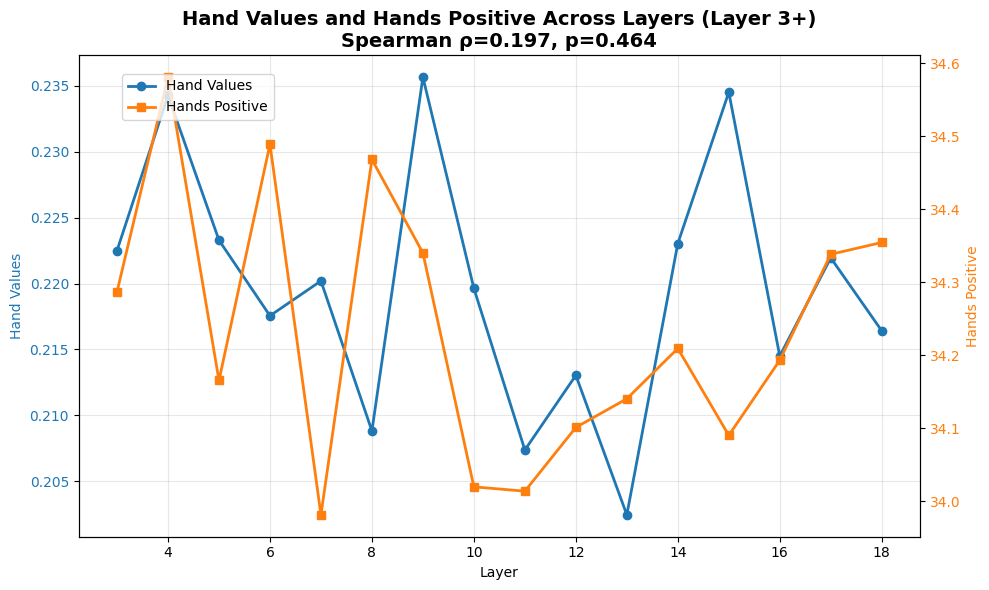

In [3]:
import torch
import json
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

hand_values = torch.tensor([
    0.210832,  # layer_0
    0.213569,  # layer_1
    0.202250,  # layer_2
    0.222501,  # layer_3
    0.234267,  # layer_4
    0.223289,  # layer_5
    0.217554,  # layer_6
    0.220197,  # layer_7
    0.208817,  # layer_8
    0.235654,  # layer_9
    0.219634,  # layer_10
    0.207371,  # layer_11
    0.213037,  # layer_12
    0.202450,  # layer_13
    0.223037,  # layer_14
    0.234514,  # layer_15
    0.214499,  # layer_16
    0.221948,  # layer_17
    0.216414,  # layer_18
])

hands_data = json.load(open('/export/home/ru63zus/repos/contrastive-skip-layer-guidance/clip_scores_text.json', "r"))
hands_tensor_positive = torch.stack([torch.tensor(hands_data[i]['positive_scores']) for i in range(50)])
hands_tensor_negative = torch.stack([torch.tensor(hands_data[i]['negative_scores']) for i in range(50)])

hands_positive = hands_tensor_positive.mean(dim=0) 
hands_negative = hands_tensor_negative.mean(dim=0)

hand_diffs = ((hands_tensor_positive - hands_tensor_negative) / hands_tensor_positive).mean(dim=0)

# Cosine similarity (existing)
correlation_diff = torch.cosine_similarity(
    hand_diffs[3:] - hand_diffs[3:].mean(), 
    hand_values[3:] - hand_values[3:].mean(), 
    dim=0
)
correlation_pos = torch.cosine_similarity(
    hands_positive[3:] - hands_positive[3:].mean(), 
    hand_values[3:] - hand_values[3:].mean(), 
    dim=0
)
correlation_neg = torch.cosine_similarity(
    hands_negative[3:] - hands_negative[3:].mean(), 
    hand_values[3:] - hand_values[3:].mean(), 
    dim=0
)

# Spearman correlation
spearman_diff, p_diff = spearmanr(hand_diffs[3:].numpy(), hand_values[3:].numpy())
spearman_pos, p_pos = spearmanr(hands_positive[3:].numpy(), hand_values[3:].numpy())
spearman_neg, p_neg = spearmanr(hands_negative[3:].numpy(), hand_values[3:].numpy())

print("=== Cosine Similarity ===")
print(f"Correlation (diff): {correlation_diff:.4f}")
print(f"Correlation (pos):  {correlation_pos:.4f}")
print(f"Correlation (neg):  {correlation_neg:.4f}")

print("\n=== Spearman Correlation ===")
print(f"Spearman (diff): {spearman_diff:.4f} (p={p_diff:.4f})")
print(f"Spearman (pos):  {spearman_pos:.4f} (p={p_pos:.4f})")
print(f"Spearman (neg):  {spearman_neg:.4f} (p={p_neg:.4f})")

# Create plot
layers = list(range(3, len(hand_values)))

fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot hand_values on primary y-axis
color1 = 'tab:blue'
ax1.set_xlabel('Layer')
ax1.set_ylabel('Hand Values', color=color1)
ax1.plot(layers, hand_values[3:].numpy(), marker='o', color=color1, label='Hand Values', linewidth=2)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.grid(True, alpha=0.3)

# Create secondary y-axis for hands_positive
ax2 = ax1.twinx()
color2 = 'tab:orange'
ax2.set_ylabel('Hands Positive', color=color2)
ax2.plot(layers, hands_positive[3:].numpy(), marker='s', color=color2, label='Hands Positive', linewidth=2)
ax2.tick_params(axis='y', labelcolor=color2)

# Add title and legends
plt.title(f'Hand Values and Hands Positive Across Layers (Layer 3+)\nSpearman ρ={spearman_pos:.3f}, p={p_pos:.3f}', 
          fontsize=14, fontweight='bold')
fig.legend(loc='upper left', bbox_to_anchor=(0.12, 0.88))

plt.tight_layout()
plt.show()